In [92]:
import pandas as pd
import numpy as np


In [93]:
PJME_data = pd.read_csv("processed_data/PJME_phase2_preprocessed.csv")

In [94]:
print("Shape:", PJME_data.shape)
print(PJME_data.columns.tolist())

print(PJME_data.head())
print(PJME_data.tail())

Shape: (145224, 16)
['Datetime', 'PJME_MW', 'Hour', 'Day', 'Week', 'Month', 'DayOfWeek', 'IsWeekend', 'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Mean_168', 'Rolling_Std_24', 'Rolling_Std_168']
              Datetime  PJME_MW  Hour  Day  Week  Month  DayOfWeek  IsWeekend  \
0  2002-01-08 01:00:00  29445.0     1    8     2      1          1          0   
1  2002-01-08 02:00:00  28670.0     2    8     2      1          1          0   
2  2002-01-08 03:00:00  28375.0     3    8     2      1          1          0   
3  2002-01-08 04:00:00  28542.0     4    8     2      1          1          0   
4  2002-01-08 05:00:00  29261.0     5    8     2      1          1          0   

     Lag_1   Lag_24   Lag_48  Lag_168  Rolling_Mean_24  Rolling_Mean_168  \
0  31187.0  26862.0  27100.0  30393.0     33452.583333      32519.511905   
1  29445.0  25976.0  26097.0  29265.0     33560.208333      32513.869048   
2  28670.0  25641.0  25793.0  28357.0     33672.458333      32510.3

In [95]:
print(PJME_data.dtypes)

Datetime                str
PJME_MW             float64
Hour                  int64
Day                   int64
Week                  int64
Month                 int64
DayOfWeek             int64
IsWeekend             int64
Lag_1               float64
Lag_24              float64
Lag_48              float64
Lag_168             float64
Rolling_Mean_24     float64
Rolling_Mean_168    float64
Rolling_Std_24      float64
Rolling_Std_168     float64
dtype: object


In [96]:
PJME_data["Datetime"] = pd.to_datetime(PJME_data["Datetime"])

# Sort
PJME_data = PJME_data.sort_values("Datetime").reset_index(drop=True)

In [97]:
validation_hours = 60 * 24
final_validation = PJME_data.iloc[-validation_hours:].copy()

training_data = PJME_data.iloc[:-validation_hours].copy()

In [98]:
print("Complete dataset :", PJME_data.shape)
print("Training data    :", training_data.shape)
print("Validation data  :", final_validation.shape)

Complete dataset : (145224, 16)
Training data    : (143784, 16)
Validation data  : (1440, 16)


In [99]:
print("Start:",training_data["Datetime"].min())
print("End:",training_data["Datetime"].max())

Start: 2002-01-08 01:00:00
End: 2018-06-04 00:00:00


In [100]:
print("Start:",final_validation["Datetime"].min())
print("End:",final_validation["Datetime"].max())

Start: 2018-06-04 01:00:00
End: 2018-08-03 00:00:00


In [101]:
from sklearn.preprocessing import StandardScaler

In [102]:
feature_columns = [
    "Hour",
    "Day",
    "Week",
    "Month",
    "DayOfWeek",
    "IsWeekend",
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Mean_168",
    "Rolling_Std_24",
    "Rolling_Std_168"
]

target_column = "PJME_MW"

In [103]:
X_train_final = training_data[feature_columns].values
y_train_final = training_data[[target_column]].values

X_val_final = final_validation[feature_columns].values
y_val_final = final_validation[[target_column]].values

print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("X_val_final:", X_val_final.shape)
print("y_val_final:", y_val_final.shape)


X_train_final: (143784, 14)
y_train_final: (143784, 1)
X_val_final: (1440, 14)
y_val_final: (1440, 1)


In [104]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled_final = feature_scaler.fit_transform(X_train_final)
y_train_scaled_final = target_scaler.fit_transform(y_train_final)


# Validation uses the SAME scalers

X_val_scaled_final = feature_scaler.transform(X_val_final)
y_val_scaled_final = target_scaler.transform(y_val_final)



print("X_train_scaled_final:",X_train_scaled_final.shape)

print("y_train_scaled_final:",y_train_scaled_final.shape)

print("X_val_scaled_final:",X_val_scaled_final.shape)

print("y_val_scaled_final:",y_val_scaled_final.shape)

X_train_scaled_final: (143784, 14)
y_train_scaled_final: (143784, 1)
X_val_scaled_final: (1440, 14)
y_val_scaled_final: (1440, 1)


In [105]:
def create_training_sequences(X, y, input_steps=48, output_steps=24):

    X_seq = []
    y_seq = []

    for i in range(input_steps, len(X) - output_steps + 1):

        X_seq.append(X[i-input_steps:i])
        y_seq.append(y[i:i+output_steps].flatten() )

    return (np.array(X_seq), np.array(y_seq))

In [106]:
X_train_seq_final, y_train_seq_final = create_training_sequences(
    X_train_scaled_final,
    y_train_scaled_final,
    input_steps=48,
    output_steps=24
)

In [107]:
print("X_train_seq_final:", X_train_seq_final.shape)
print("y_train_seq_final:",y_train_seq_final.shape)

X_train_seq_final: (143713, 48, 14)
y_train_seq_final: (143713, 24)


In [108]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [110]:
from tensorflow.keras.optimizers import RMSprop

final_rnn_model = Sequential([SimpleRNN(64,input_shape=(48, 14),return_sequences=False),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),                                           
    Dense(24)
])

final_rnn_model.compile(
    optimizer=RMSprop(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

final_rnn_model.summary()

/Users/aximsoft/tfenv/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_4 (SimpleRNN)        │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,088 (47.22 KB)

 Trainable params: 12,088 (47.22 KB)

 Non-trainable params: 0 (0.00 B)

In [111]:
final_rnn_history = final_rnn_model.fit(
    X_train_seq_final,
    y_train_seq_final,
    epochs=20,
    batch_size=64,
    verbose=1
)

Epoch 1/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.1275 - mae: 0.2589
Epoch 2/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 0.0874 - mae: 0.2136
Epoch 3/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0821 - mae: 0.2055
Epoch 4/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0790 - mae: 0.2007
Epoch 5/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0770 - mae: 0.1975
Epoch 6/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0754 - mae: 0.1950
Epoch 7/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0742 - mae: 0.1932
Epoch 8/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0733 - mae: 0.1918
Epoch 9/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0724 - mae: 0.1904
Epoch 10/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 0.0715 - mae: 0.1893
Epoch 11/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0709 - mae: 0.1883
Epoch 12/20
2246/2246 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0701 - mae: 0.1872


In [112]:
final_rnn_model.save("final_rnn_48h_to_24h_rmsprop.keras")
print("model saved successfully.")

model saved successfully.


In [113]:
import matplotlib.pyplot as plt

In [114]:
forecast_rolling = []
actual_rolling = []
forecast_dates = []

combined_data = pd.concat(
    [training_data, final_validation],
    ignore_index=True
).copy()

combined_data["Datetime"] = pd.to_datetime(combined_data["Datetime"])

num_windows = len(final_validation) // 24

print("Forecast windows:", num_windows)

for window in range(num_windows):

    start = window * 24
    end = start + 24

    validation_window = final_validation.iloc[start:end]

    forecast_start_datetime = validation_window["Datetime"].iloc[0]

    # Previous 48 hours
    previous_48 = combined_data[
        combined_data["Datetime"] < forecast_start_datetime
    ].tail(48).copy()

    X_input = previous_48[feature_columns].values

    X_input_scaled = feature_scaler.transform(X_input)

    # RNN input: 1 sample, 48 hours, 14 features
    X_input_scaled = X_input_scaled.reshape(1, 48, 14)

    # Predict next 24 hours
    prediction_scaled = final_rnn_model.predict(
        X_input_scaled,
        verbose=0
    )

    # Convert back to MW
    prediction = target_scaler.inverse_transform(
        prediction_scaled.reshape(-1, 1)
    ).flatten()

    forecast_rolling.extend(prediction)

    actual_rolling.extend(
        validation_window["PJME_MW"].values
    )

    forecast_dates.extend(
        validation_window["Datetime"].values
    )

    print(f"Window {window + 1}/{num_windows} completed")


forecast_rolling = np.array(forecast_rolling)
actual_rolling = np.array(actual_rolling)
forecast_dates = pd.to_datetime(forecast_dates)

print("Rolling completed")

print("Forecast:", forecast_rolling.shape)
print("Actual:", actual_rolling.shape)

Forecast windows: 60
Window 1/60 completed
Window 2/60 completed
Window 3/60 completed
Window 4/60 completed
Window 5/60 completed
Window 6/60 completed
Window 7/60 completed
Window 8/60 completed
Window 9/60 completed
Window 10/60 completed
Window 11/60 completed
Window 12/60 completed
Window 13/60 completed
Window 14/60 completed
Window 15/60 completed
Window 16/60 completed
Window 17/60 completed
Window 18/60 completed
Window 19/60 completed
Window 20/60 completed
Window 21/60 completed
Window 22/60 completed
Window 23/60 completed
Window 24/60 completed
Window 25/60 completed
Window 26/60 completed
Window 27/60 completed
Window 28/60 completed
Window 29/60 completed
Window 30/60 completed
Window 31/60 completed
Window 32/60 completed
Window 33/60 completed
Window 34/60 completed
Window 35/60 completed
Window 36/60 completed
Window 37/60 completed
Window 38/60 completed
Window 39/60 completed
Window 40/60 completed
Window 41/60 completed
Window 42/60 completed
Window 43/60 completed

In [115]:
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

mae = mean_absolute_error(actual_rolling, forecast_rolling)
rmse = np.sqrt(mean_squared_error(actual_rolling, forecast_rolling))
mape = np.mean(np.abs((actual_rolling - forecast_rolling)/ actual_rolling)) * 100
r2 = r2_score(actual_rolling, forecast_rolling)
bias = np.mean(forecast_rolling - actual_rolling)

print("== RNN RMSprop ==")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"MAPE : {mape:.6f}%")
print(f"R²   : {r2:.6f}")
print(f"Bias : {bias:.6f}")

== RNN RMSprop ==
MAE  : 1945.609527
RMSE : 2739.147156
MAPE : 5.341999%
R²   : 0.873378
Bias : 282.692963


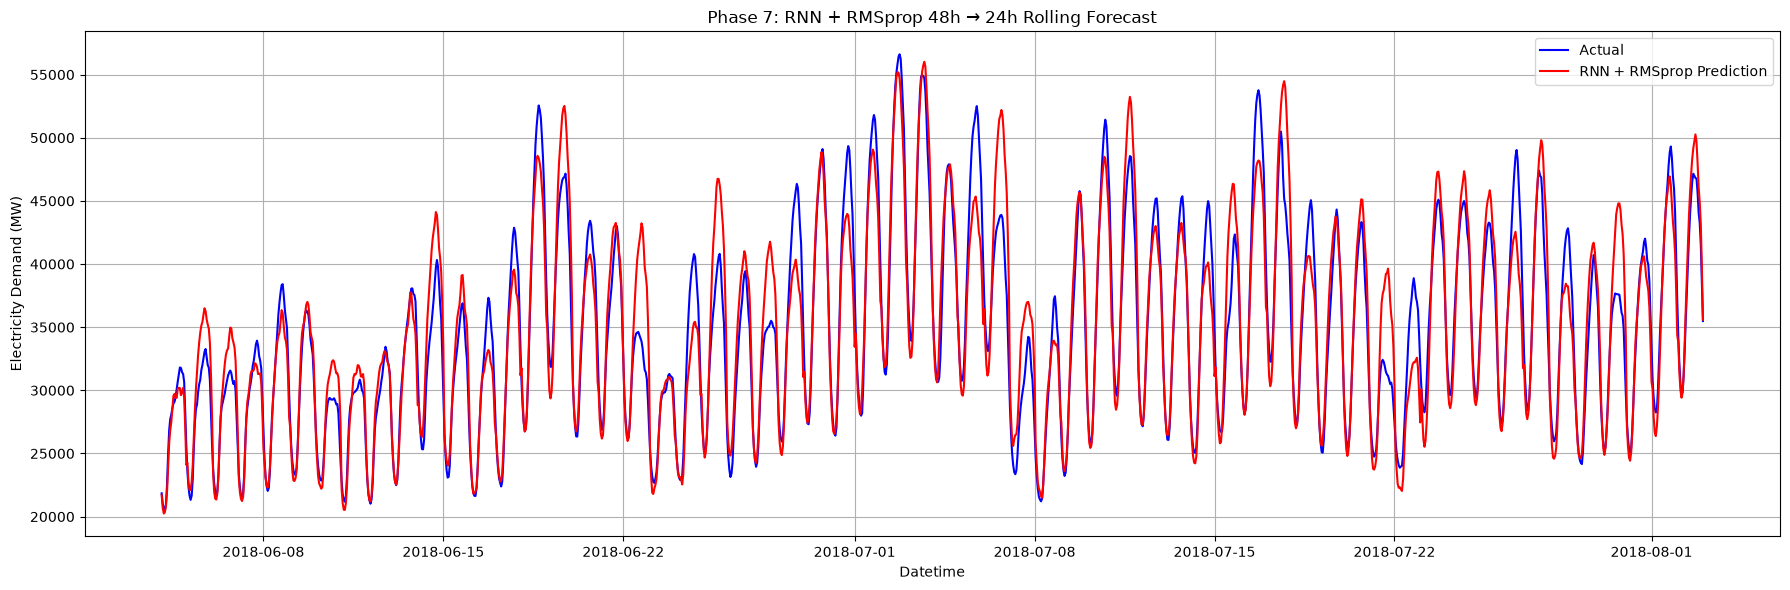

In [116]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.plot(forecast_dates,actual_rolling,label="Actual",color="blue")
plt.plot(forecast_dates,forecast_rolling, label="RNN + RMSprop Prediction", color="red")
plt.title("Phase 7: RNN + RMSprop 48h → 24h Rolling Forecast")
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig(
    "phase7_rnn_48h_to_24h_rmsprop_forecast.png",
    dpi=300
)
plt.show()

In [117]:
# 30 day performance

actual_30 = actual_rolling[:720]
predicted_30 = forecast_rolling[:720]

mae_30 = mean_absolute_error(actual_30, predicted_30)
rmse_30 = np.sqrt(mean_squared_error(actual_30, predicted_30))
mape_30 = np.mean(np.abs((actual_30 - predicted_30) / actual_30)) * 100
r2_30 = r2_score(actual_30, predicted_30) 
bias_30 = np.mean(predicted_30 - actual_30)

print("\n======================================")
print("PHASE 7 - 30 DAY RESULTS")
print("======================================")

print("MAE :", mae_30)
print("RMSE:", rmse_30)
print("MAPE:", mape_30)
print("R²  :", r2_30)
print("Bias:", bias_30)


PHASE 7 - 30 DAY RESULTS
MAE : 1760.4446451822917
RMSE: 2485.4733423173907
MAPE: 5.014282326881961
R²  : 0.8998047358504945
Bias: 304.7603515625


In [118]:
# 30 day vs 60 day comparison

phase7_comparison = pd.DataFrame({
    "Period": ["30 Days", "60 Days"],
    "MAE": [mae_30, mae],
    "RMSE": [rmse_30, rmse],
    "MAPE": [mape_30, mape],
    "R2": [r2_30, r2],
    "Bias": [bias_30, bias]
})

display(
    phase7_comparison.style.format({
        "MAE": "{:.6f}",
        "RMSE": "{:.6f}",
        "MAPE": "{:.6f}",
        "R2": "{:.6f}",
        "Bias": "{:.6f}"
    })
)

,Period,MAE,RMSE,MAPE,R2,Bias
0,30 Days,1760.444645,2485.473342,5.014282,0.899805,304.760352
1,60 Days,1945.609527,2739.147156,5.341999,0.873378,282.692963


In [119]:
import os
import matplotlib.pyplot as plt

os.makedirs("images", exist_ok=True)

# Daily error

results_df = pd.DataFrame({
    "Datetime": forecast_dates,
    "Actual": actual_rolling,
    "Forecast": forecast_rolling
})

results_df["Error"] = results_df["Forecast"] - results_df["Actual"]
results_df["Absolute_Error"] = results_df["Error"].abs()
results_df["APE"] = (
    results_df["Absolute_Error"] / results_df["Actual"]
) * 100

results_df["Date"] = results_df["Datetime"].dt.date

daily_error = results_df.groupby("Date").agg(
    Actual=("Actual", "mean"),
    Forecast=("Forecast", "mean"),
    MAE=("Absolute_Error", "mean"),
    Bias=("Error", "mean"),
    MAPE=("APE", "mean")
).reset_index()

print(daily_error.head())

         Date        Actual      Forecast          MAE         Bias      MAPE
0  2018-06-04  27323.478261  26662.320312   768.465948  -661.158543  2.676847
1  2018-06-05  28280.958333  30398.669922  2244.175700  2117.710205  7.522052
2  2018-06-06  27839.000000  29353.134766  1702.125651  1514.134928  5.754392
3  2018-06-07  28615.708333  28168.341797   764.774577  -447.367188  2.539688
4  2018-06-08  30924.625000  30025.093750  1005.654622  -899.531901  2.911241


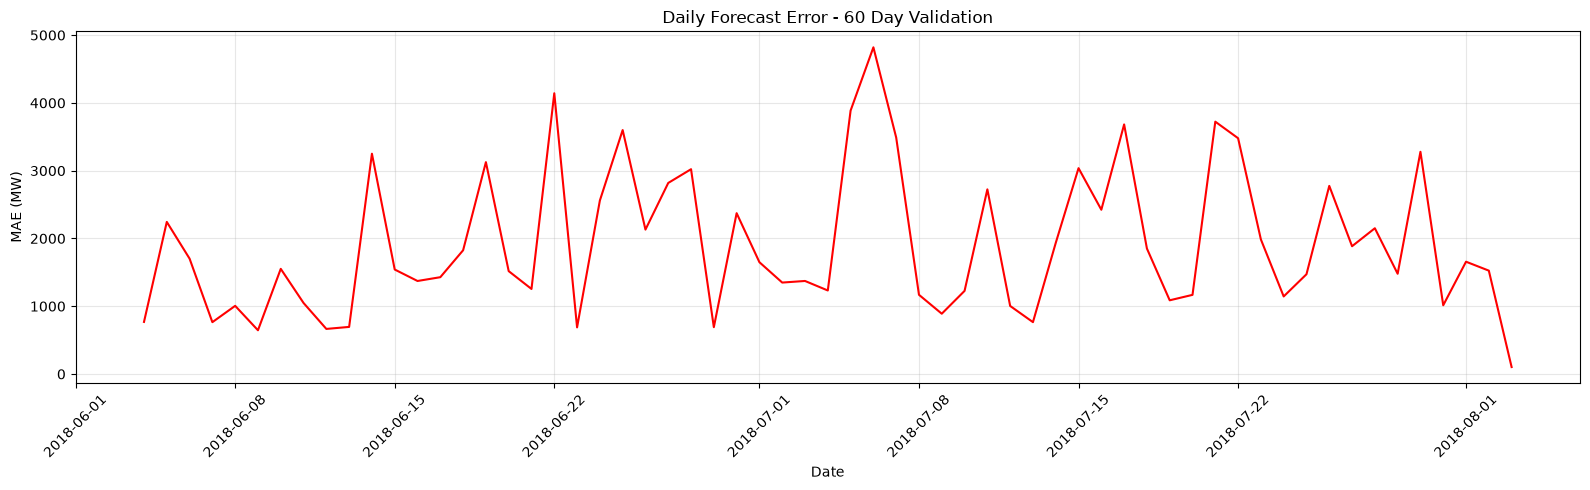

In [120]:
plt.figure(figsize=(16, 5))

plt.plot(
    daily_error["Date"],
    daily_error["MAE"],
    color="red"
)

plt.title("Daily Forecast Error - 60 Day Validation")
plt.xlabel("Date")
plt.ylabel("MAE (MW)")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "images/phase7_daily_error_60days.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [121]:
# daily error 30 days
results_30 = results_df.iloc[:720].copy()

results_30["Date"] = results_30["Datetime"].dt.date

daily_error_30 = results_30.groupby("Date").agg(
    Actual=("Actual", "mean"),
    Forecast=("Forecast", "mean"),
    MAE=("Absolute_Error", "mean"),
    Bias=("Error", "mean"),
    MAPE=("APE", "mean")
).reset_index()

display(daily_error_30.head())

,Date,Actual,Forecast,MAE,Bias,MAPE
0,2018-06-04,27323.478261,26662.320312,768.465948,-661.158543,2.676847
1,2018-06-05,28280.958333,30398.669922,2244.175700,2117.710205,7.522052
2,2018-06-06,27839.000000,29353.134766,1702.125651,1514.134928,5.754392
3,2018-06-07,28615.708333,28168.341797,764.774577,-447.367188,2.539688
4,2018-06-08,30924.625000,30025.093750,1005.654622,-899.531901,2.911241


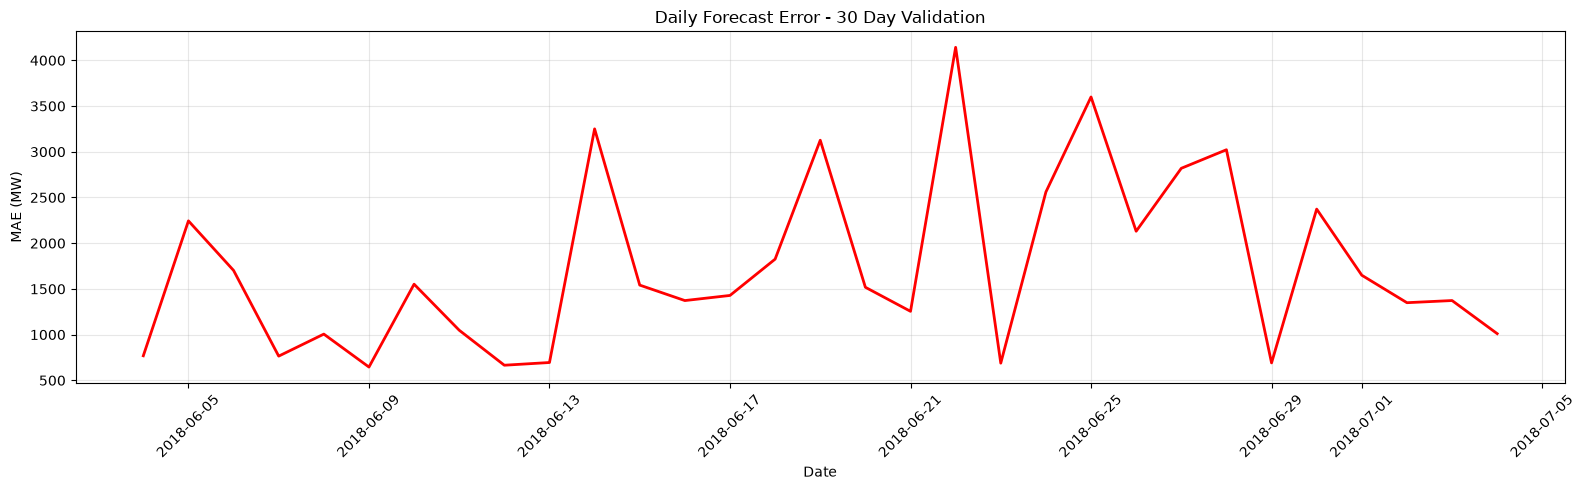

In [122]:
plt.figure(figsize=(16, 5))
plt.plot(daily_error_30["Date"],daily_error_30["MAE"],color="red",linewidth=2)
plt.title("Daily Forecast Error - 30 Day Validation")
plt.xlabel("Date")
plt.ylabel("MAE (MW)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/phase7_daily_error_30days.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [123]:
peak_threshold = np.percentile(actual_rolling, 90)
peak_mask = actual_rolling >= peak_threshold
peak_actual = actual_rolling[peak_mask]
peak_predicted = forecast_rolling[peak_mask]

peak_mae = mean_absolute_error(
    peak_actual,
    peak_predicted
)

peak_rmse = np.sqrt(
    mean_squared_error(
        peak_actual,
        peak_predicted
    )
)
peak_mape = np.mean(np.abs((peak_actual - peak_predicted) / peak_actual)) * 100

print("--PHASE 7 - PEAK DEMAND PERFORMANCE--")
print("Peak threshold:", peak_threshold, "MW")
print("Peak observations:", len(peak_actual))
print("Peak MAE:", peak_mae)
print("Peak RMSE:", peak_rmse)
print("Peak MAPE:", peak_mape)

--PHASE 7 - PEAK DEMAND PERFORMANCE--
Peak threshold: 45476.9 MW
Peak observations: 144
Peak MAE: 3159.5068088107637
Peak RMSE: 3777.598196631339
Peak MAPE: 6.465600064149024


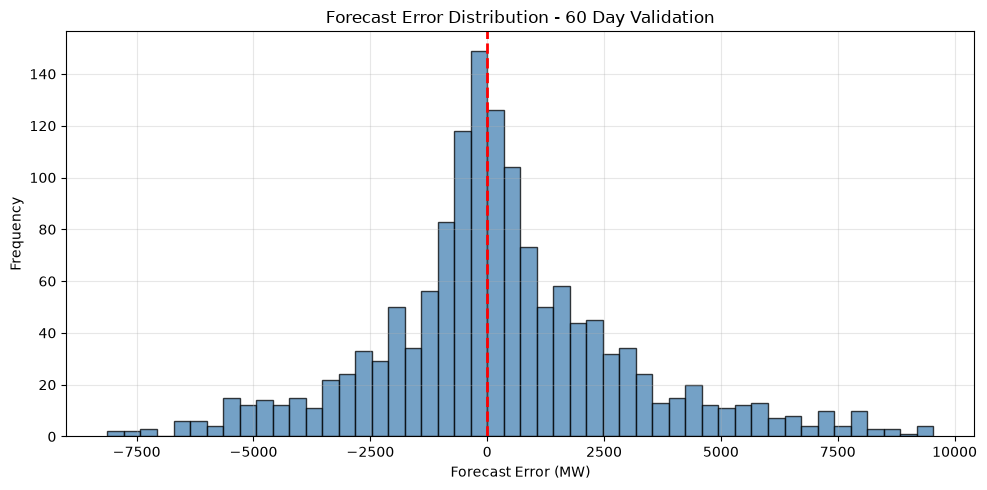

In [124]:
errors = forecast_rolling - actual_rolling

plt.figure(figsize=(10, 5))
plt.hist( errors, bins=50, color="steelblue", edgecolor="black", alpha=0.75)
plt.axvline( 0, color="red", linestyle="--", linewidth=2)
plt.title("Forecast Error Distribution - 60 Day Validation")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/phase7_forecast_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

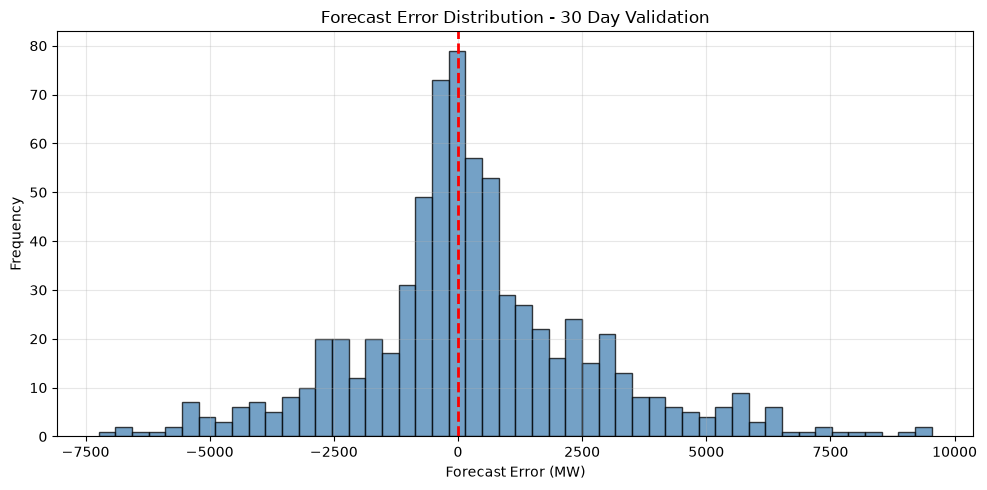

In [125]:
# PHASE 7 - 30 DAY FORECAST ERROR

actual_30 = actual_rolling[:720]
predicted_30 = forecast_rolling[:720]
errors_30 = predicted_30 - actual_30

plt.figure(figsize=(10, 5))
plt.hist(errors_30, bins=50, color="steelblue", edgecolor="black", alpha=0.75)
plt.axvline( 0, color="red", linestyle="--", linewidth=2)
plt.title("Forecast Error Distribution - 30 Day Validation")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/phase7_forecast_error_distribution_30days.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [127]:
# 30 Days Peak Demand Performance

phase7_results = [
    {
        "Validation": "30 Days",
        "MAE": mae_30,
        "RMSE": rmse_30,
        "MAPE": mape_30,
        "R2": r2_30,
        "Bias": bias_30
    },

    {
        "Validation": "60 Days",
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "R2": r2,
        "Bias": bias
    },

    {
        "Validation": "30 Days Peak Demand",
        "MAE": peak_mae_30,
        "RMSE": peak_rmse_30,
        "MAPE": peak_mape_30,
        "R2": np.nan,
        "Bias": np.nan
    },

    {
        "Validation": "60 Days Peak Demand",
        "MAE": peak_mae,
        "RMSE": peak_rmse,
        "MAPE": peak_mape,
        "R2": np.nan,
        "Bias": np.nan
    }
]

phase7_results_df = pd.DataFrame(phase7_results)

display(
    phase7_results_df.style.format({
        "MAE": "{:.6f}",
        "RMSE": "{:.6f}",
        "MAPE": "{:.6f}",
        "R2": "{:.6f}",
        "Bias": "{:.6f}"
    })
)

# Save CSV
phase7_results_df.to_csv(
    "phase7_final_results.csv",
    index=False
)

print("Phase 7 final results saved successfully.")

,Validation,MAE,RMSE,MAPE,R2,Bias
0,30 Days,1760.444645,2485.473342,5.014282,0.899805,304.760352
1,60 Days,1945.609527,2739.147156,5.341999,0.873378,282.692963
2,30 Days Peak Demand,2680.541124,3255.570997,5.509521,nan,nan
3,60 Days Peak Demand,3159.506809,3777.598197,6.465600,nan,nan


Phase 7 final results saved successfully.


## Phase 8 Model Comparison

In [128]:
phase4_results = pd.read_csv("processed_data/phase4_baseline_results.csv")

In [129]:
phase4_results

,Model,MAE,RMSE,MAPE,R2,Bias
0,Naive(1Hr),1054.538423,1354.455901,3.426626,0.955795,-0.203314
1,Naive(24Hr),2206.332124,3027.407171,7.013357,0.779157,-9.834695
2,Moving Average,3558.373439,4468.461840,11.718028,0.518875,-6.741366
3,Previous Day,2206.332124,3027.407171,7.013357,0.779157,-9.834695
4,Previous Week,3434.415810,4735.138844,10.698904,0.459735,-41.495501


In [130]:
phase5_results = pd.read_csv("models/phase5/phase5_all_results.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'models/phase5/phase5_all_results.csv'

In [131]:
phase5_results

NameError: name 'phase5_results' is not defined

In [8]:
# best model

best_mae = phase5_results.loc[phase5_results["MAE"].idxmin()]
best_rmse = phase5_results.loc[ phase5_results["RMSE"].idxmin()]
best_mape = phase5_results.loc[phase5_results["MAPE"].idxmin()]
best_r2 = phase5_results.loc[phase5_results["R2"].idxmax()]

print("BEST MODEL BY EACH METRIC")

print(best_mae)
print(best_rmse)
print(best_mape)
print(best_r2)

BEST MODEL BY EACH METRIC
Rank                      1
Model                   RNN
Input_Hours              24
Output_Hours             24
MAE             1376.715652
RMSE            1926.890466
MAPE               4.347443
R2                  0.91054
Bias              78.356911
Name: 0, dtype: object
Rank                      1
Model                   RNN
Input_Hours              24
Output_Hours             24
MAE             1376.715652
RMSE            1926.890466
MAPE               4.347443
R2                  0.91054
Bias              78.356911
Name: 0, dtype: object
Rank                      1
Model                   RNN
Input_Hours              24
Output_Hours             24
MAE             1376.715652
RMSE            1926.890466
MAPE               4.347443
R2                  0.91054
Bias              78.356911
Name: 0, dtype: object
Rank                      1
Model                   RNN
Input_Hours              24
Output_Hours             24
MAE             1376.715652
RMSE     

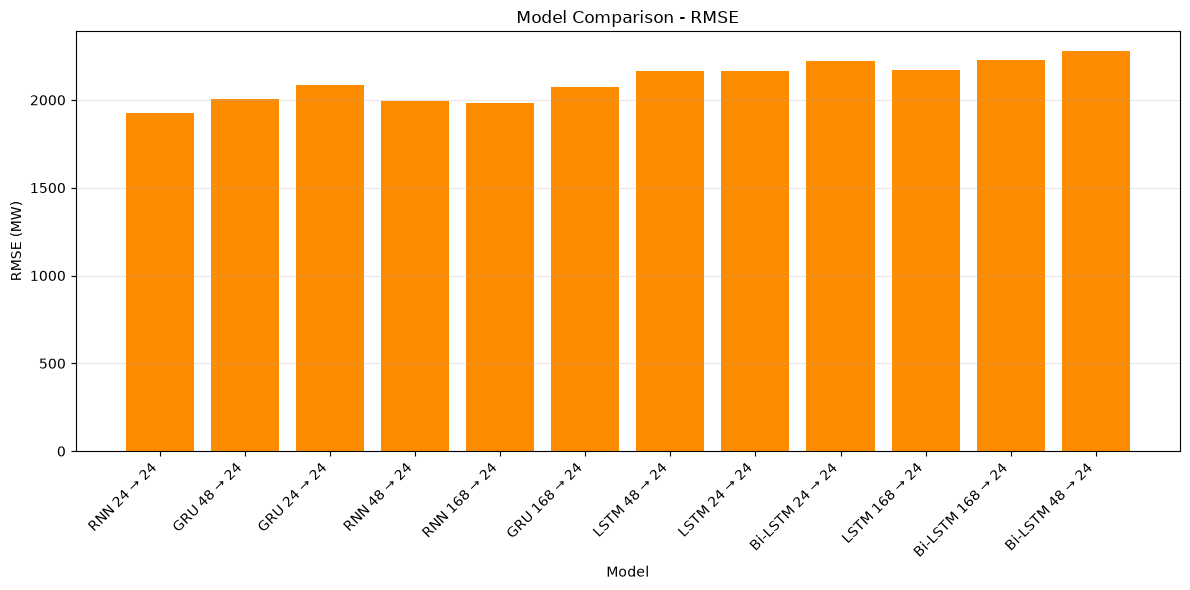

In [60]:
# RMSE comparison
plt.figure(figsize=(12, 6))

plt.bar(labels, phase8_df["RMSE"], color="darkorange")

plt.title("Model Comparison - RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE (MW)")

plt.xticks(rotation=45,ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/phase8_rmse_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

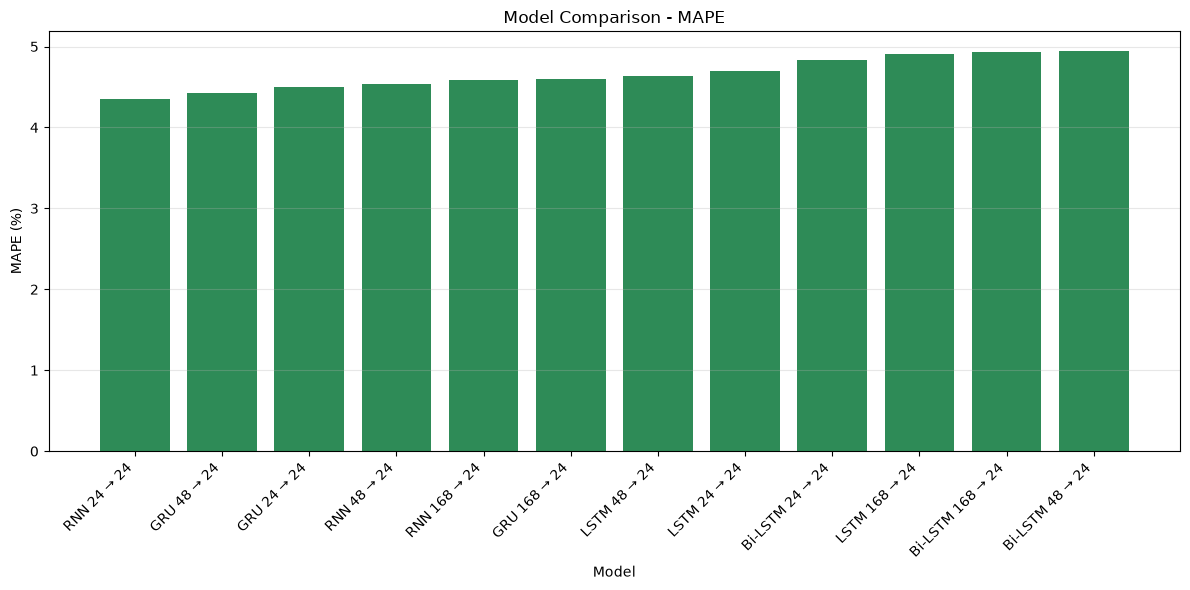

In [61]:
# mape comparison
plt.figure(figsize=(12, 6))
plt.bar(labels, phase8_df["MAPE"], color="seagreen")

plt.title("Model Comparison - MAPE")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "images/phase8_mape_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

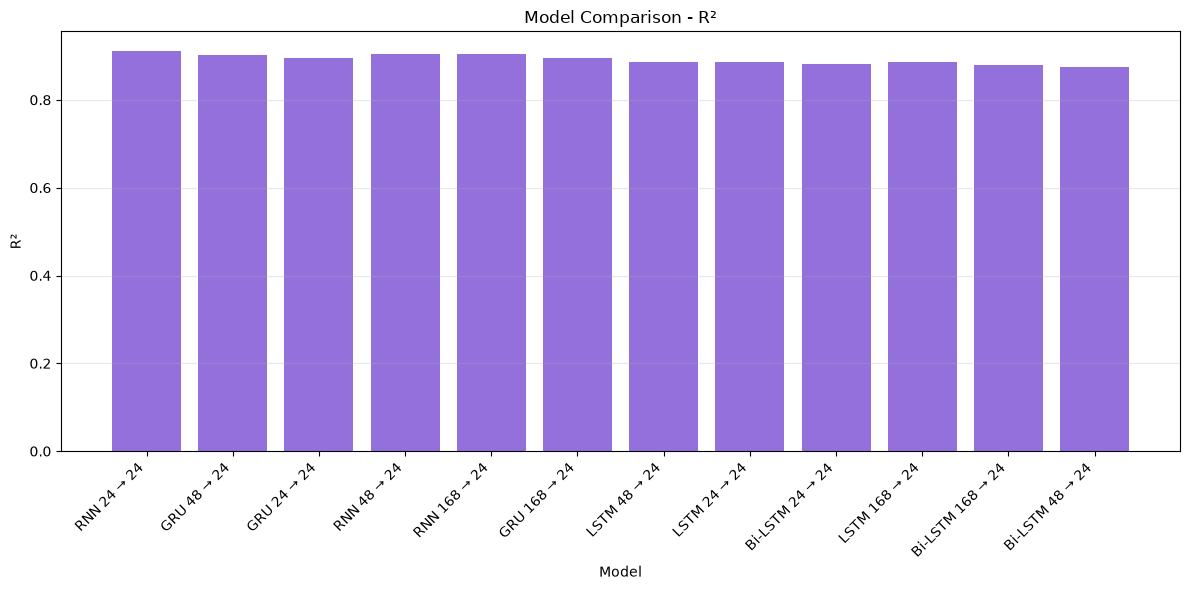

In [62]:
#r2 comparison
plt.figure(figsize=(12, 6))

plt.bar(labels, phase8_df["R2"], color="mediumpurple")

plt.title("Model Comparison - R²")
plt.xlabel("Model")
plt.ylabel("R²")

plt.xticks(rotation=45, ha="right")
plt.grid( axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/phase8_r2_comparison.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [63]:
# final unseen validation
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

final_mae = mean_absolute_error( actual_rolling, forecast_rolling)
final_rmse = np.sqrt(mean_squared_error( actual_rolling, forecast_rolling))
final_mape = np.mean(np.abs((actual_rolling - forecast_rolling)/actual_rolling))*100

final_r2 = r2_score(actual_rolling, forecast_rolling)
final_bias = np.mean(forecast_rolling - actual_rolling)

print("======================================")
print("FINAL RNN 24 → 24")
print("60-DAY UNSEEN TEST")
print("======================================")

print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("MAPE:", final_mape)
print("R²  :", final_r2)
print("Bias:", final_bias)

FINAL RNN 24 → 24
60-DAY UNSEEN TEST
MAE : 1849.6819132486978
RMSE: 2600.5815646552323
MAPE: 5.076388045821296
R²  : 0.8858652326189403
Bias: 363.8615736219618


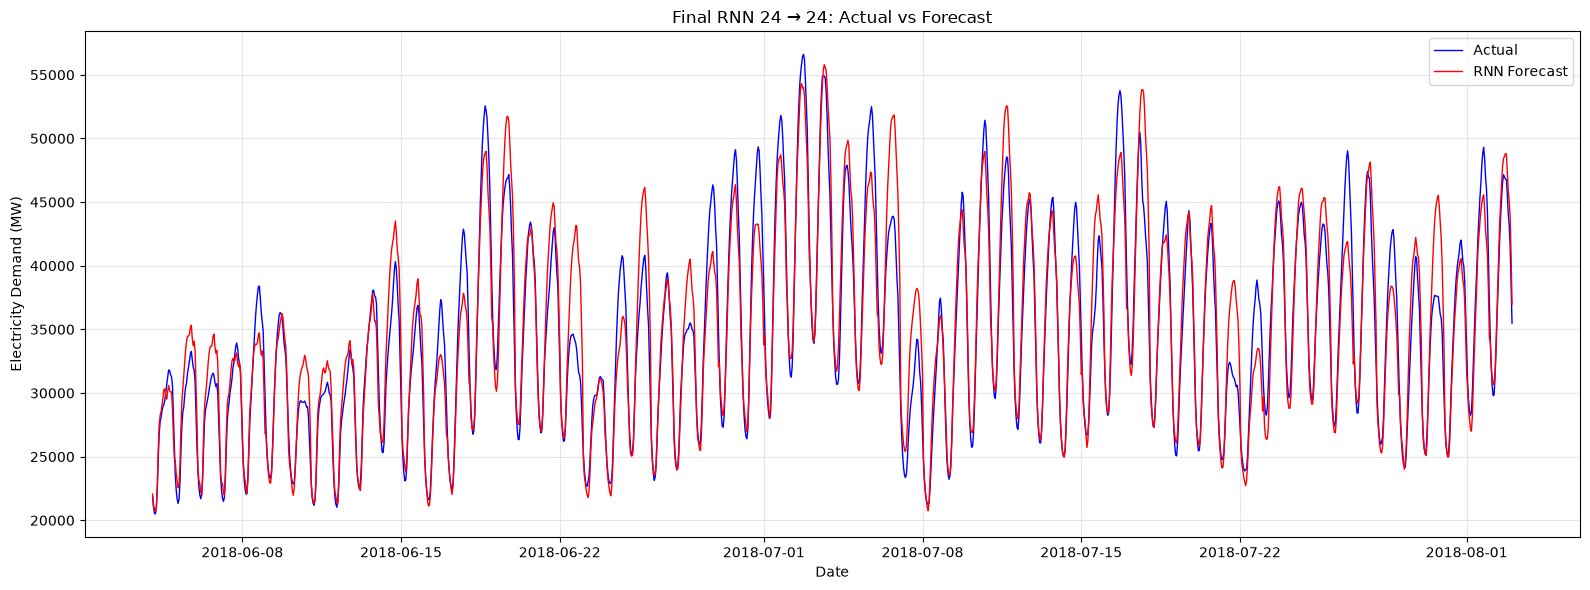

In [64]:
# final actual vs forecast
plt.figure(figsize=(16, 6))

plt.plot( forecast_dates, actual_rolling, label="Actual", color="blue", linewidth=1)
plt.plot(forecast_dates, forecast_rolling, label="RNN Forecast", color="red", linewidth=1)

plt.title("Final RNN 24 → 24: Actual vs Forecast")
plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/phase8_final_actual_vs_forecast.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

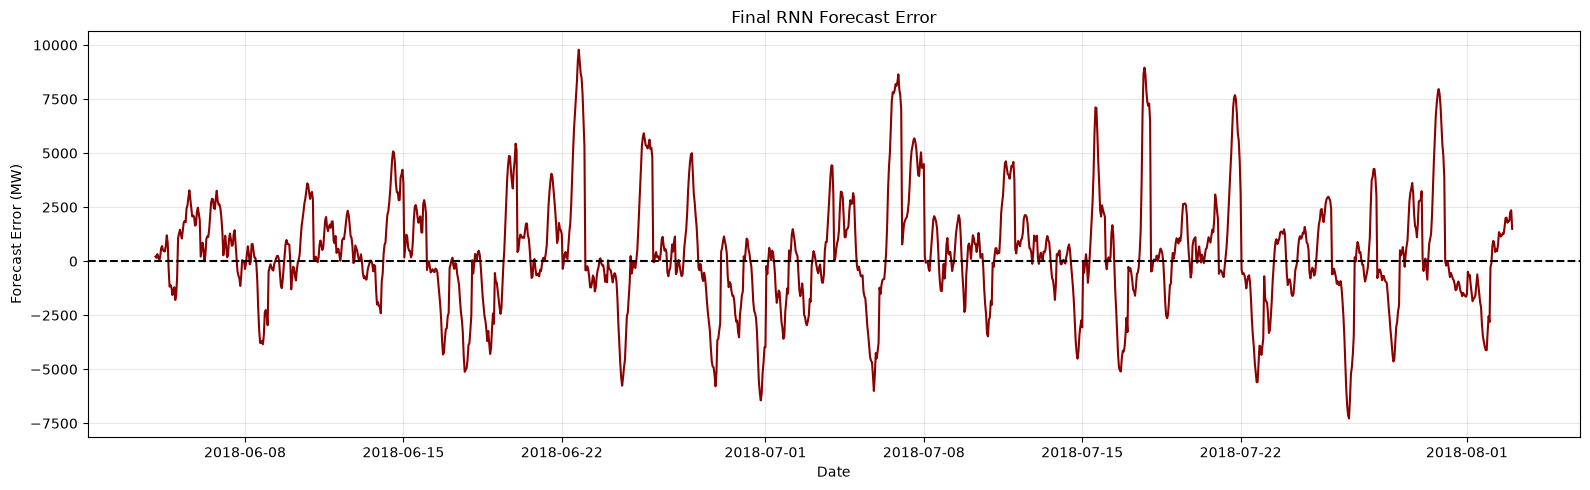

In [65]:
# forecast error
final_errors = (forecast_rolling -actual_rolling)

plt.figure(figsize=(16, 5))
plt.plot( forecast_dates, final_errors, color="darkred")
plt.axhline( 0, color="black", linestyle="--")
plt.title("Final RNN Forecast Error")
plt.xlabel("Date")
plt.ylabel("Forecast Error (MW)")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/phase8_forecast_error.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

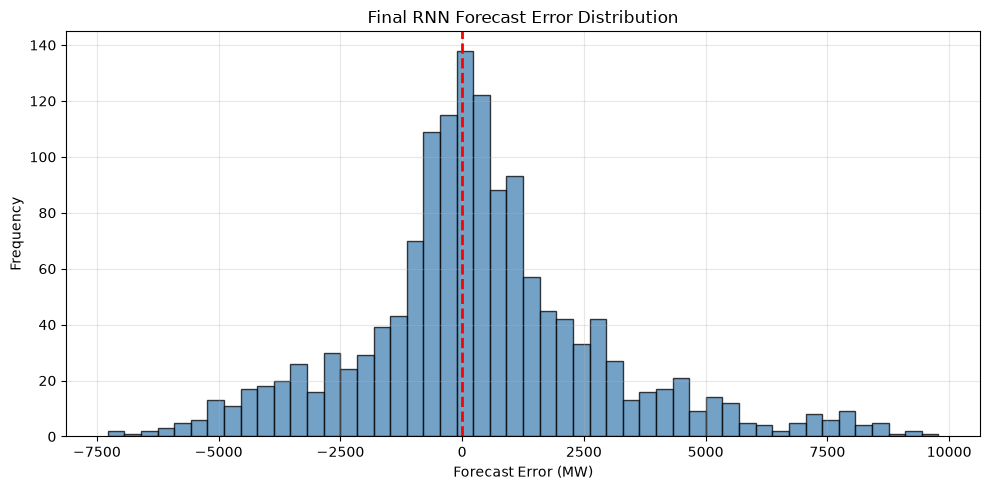

In [66]:
# error distribution
plt.figure(figsize=(10, 5))

plt.hist(final_errors, bins=50, color="steelblue", edgecolor="black", alpha=0.75)
plt.axvline(0, color="red", linestyle="--", linewidth=2)

plt.title("Final RNN Forecast Error Distribution")
plt.xlabel("Forecast Error (MW)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "images/phase8_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [13]:
import pandas as pd

phase6_results = [

    # Early Stopping
    {
        "Technique": "Early Stopping",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1390.3678448612964,
    "RMSE": 1949.1159618860881,
    "MAPE": 4.410774413858794,
    "R2": 0.9084643650051681,
    "Bias": 120.65475509308246
    },

    # Dropout
    {
        "Technique": "Dropout",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1471.529424933611,
        "RMSE": 2009.527278024123,
        "MAPE":4.691583628341732,
        "R2": 0.9027022820804059,
        "Bias": 117.89846316413617
    },



    # Batch Normalization
    {
        "Technique": "Batch Normalization",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1388.6084414431793,
        "RMSE": 1960.869031599301,
        "MAPE": 4.408847433340167,
        "R2": 0.9073571263344717,
        "Bias": 216.50879045895846
    },

    # Adam
    {
        "Technique": "Adam",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1412.8646858513553,
        "RMSE": 1960.2076349436081,
        "MAPE": 4.477067885744956,
        "R2": 0.907419612254838,
        "Bias": 138.76057845742451
    },

    # RMSprop
    {
        "Technique": "RMSprop",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1387.1081347502004,
        "RMSE": 1931.1706843661027,
        "MAPE": 4.41234224260603,
        "R2": 0.9101421211213101,
        "Bias": 273.0465344812776
    },

    # RMSprop + Learning Rate
    {
        "Technique": "RMSprop + Learning Rate Scheduler",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1380.455857086755,
        "RMSE": 1947.0097018210615,
        "MAPE": 4.373047915495958,
        "R2": 0.9086620891892203,
        "Bias": 183.9371604022663
    },

    # SGD
    {
        "Technique": "SGD",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1611.0813879169339,
        "RMSE": 2180.9567945231242,
        "MAPE": 5.1341236813930715,
        "R2": 0.8853935746511137,
        "Bias": 159.78651111047816
    },

    # Deep RNN
    {
        "Technique": "Deep RNN",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1499.4187534323676,
        "RMSE": 2093.1793458589927,
        "MAPE": 4.784466855917797,
        "R2": 0.8944331108299858,
        "Bias": 383.87631982172536
    },

    # 128 Neurons
    {
        "Technique": "128 Neurons",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1458.0408453731266,
        "RMSE": 2046.0232695734032,
        "MAPE": 4.657677636162435,
        "R2": 0.8991360481426458,
        "Bias": 522.2727100125278
    },

    # 32 Neurons
    {
        "Technique": "32 Neurons",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1410.3121300246148,
        "RMSE": 1985.078525099613,
        "MAPE": 4.47974784559913,
        "R2": 0.9050554097075454,
        "Bias": 226.44287729357634
    },

    # Batch Size 32
    {
        "Technique": "Batch Size 32",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1387.2739250699174,
        "RMSE": 1961.7285185939083,
        "MAPE": 4.396921367341186,
        "R2": 0.907275894192556,
        "Bias": 200.6896267575759
    },

    # Batch Size 128
    {
        "Technique": "Batch Size 128",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1399.362004928143,
        "RMSE": 1976.6945657083681,
        "MAPE": 4.432770661562494,
        "R2": 0.9058557111624999,
        "Bias": 102.18250054016362
    },

    # Hyperparameter Tuning
    {
        "Technique": "Hyperparameter Tuning",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1502.1588268103073,
        "RMSE": 2068.5658742427486,
        "MAPE": 4.816308814578437,
        "R2": 0.8969012134051946,
        "Bias": 495.7678921709132
    },


    # Additional Lags
    {
        "Technique": "Additional Lags",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1518.6297064285338,
        "RMSE": 2115.73965431117,
        "MAPE": 4.899385060780936,
        "R2": 0.8921897490234234,
        "Bias": 368.47112271678037
    },

    # Best Baseline
    {
        "Technique": "Baseline",
        "Model": "RNN",
        "Input_Output": "24 → 24",
        "MAE": 1376.7156520411265,
        "RMSE": 1926.8904657690284,
        "MAPE": 4.347443014548393,
        "R2": 0.9105399990964322,
        "Bias": 78.35691115307425
    }
]

phase6_df = pd.DataFrame(phase6_results)

# Sort by MAPE
phase6_df = phase6_df.sort_values(
    by="MAPE",
    ascending=True
).reset_index(drop=True)

phase6_df.insert(
    0,
    "Rank",
    range(1, len(phase6_df) + 1)
)

# Display
display(phase6_df)



,Rank,Technique,Model,Input_Output,MAE,RMSE,MAPE,R2,Bias
0,1,Baseline,RNN,24 → 24,1376.715652,1926.890466,4.347443,0.910540,78.356911
1,2,RMSprop + Learning Rate Scheduler,RNN,24 → 24,1380.455857,1947.009702,4.373048,0.908662,183.937160
2,3,Batch Size 32,RNN,24 → 24,1387.273925,1961.728519,4.396921,0.907276,200.689627
3,4,Batch Normalization,RNN,24 → 24,1388.608441,1960.869032,4.408847,0.907357,216.508790
4,5,Early Stopping,RNN,24 → 24,1390.367845,1949.115962,4.410774,0.908464,120.654755
5,6,RMSprop,RNN,24 → 24,1387.108135,1931.170684,4.412342,0.910142,273.046534
6,7,Batch Size 128,RNN,24 → 24,1399.362005,1976.694566,4.432771,0.905856,102.182501
7,8,Adam,RNN,24 → 24,1412.864686,1960.207635,4.477068,0.907420,138.760578
8,9,32 Neurons,RNN,24 → 24,1410.312130,1985.078525,4.479748,0.905055,226.442877
9,10,128 Neurons,RNN,24 → 24,1458.040845,2046.023270,4.657678,0.899136,522.272710


In [67]:
# peak demandd eval
peak_threshold = np.percentile(actual_rolling, 90)

peak_mask = ( actual_rolling >= peak_threshold)
peak_actual = actual_rolling[peak_mask]
peak_forecast = forecast_rolling[peak_mask]
peak_mae = mean_absolute_error(peak_actual, peak_forecast)
peak_rmse = np.sqrt(mean_squared_error( peak_actual,peak_forecast))

peak_mape = np.mean(np.abs((peak_actual - peak_forecast)/peak_actual))*100

print("=====================")
print("PEAK DEMAND EVALUATION")
print("======================")

print("Peak threshold:", peak_threshold, "MW")
print("Peak observations:", len(peak_actual))
print("Peak MAE:", peak_mae)
print("Peak RMSE:", peak_rmse)
print("Peak MAPE:",peak_mape)

PEAK DEMAND EVALUATION
Peak threshold: 45476.9 MW
Peak observations: 144
Peak MAE: 3081.2243923611113
Peak RMSE: 3508.0712889038446
Peak MAPE: 6.307648713294069


In [68]:
# eval table
final_evaluation = pd.DataFrame({

    "Evaluation": ["30-Day Validation","60-Day Validation","60-Day Peak Demand"],
    "MAE": [1707.650250, 1849.681913, 3081.224392],
    "RMSE": [2395.668891, 2600.581565, 3508.071289],
    "MAPE": [4.844191, 5.076388, 6.307649],
    "R2": [0.906914, 0.885865, np.nan],
    "Bias": [235.724750, 363.861574, np.nan]
})

display(final_evaluation)

,Evaluation,MAE,RMSE,MAPE,R2,Bias
0,30-Day Validation,1707.650250,2395.668891,4.844191,0.906914,235.724750
1,60-Day Validation,1849.681913,2600.581565,5.076388,0.885865,363.861574
2,60-Day Peak Demand,3081.224392,3508.071289,6.307649,NaN,NaN
